# Momentum Strategy

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf

## ADX: Identifying Trend Strength

Before committing to a momentum strategy, it's important to identify whether the market is trending or ranging. The Average Directional Index (ADX) is a technical indicator that helps traders determine the strength of a trend.

ADX is calculated with the following steps:
1. Calculate the True Range (TR) for each period.
2. Calculate the Directional Movement (DM) for each period.
3. Smooth the TR and DM values over a specified number of periods (commonly 14).
4. Calculate the Directional Indicators (+DI and -DI) using the smoothed DM values.
5. Calculate DX as the absolute difference between +DI and -DI, divided by the sum of +DI and -DI, multiplied by 100.
6. Finally, smooth the DX values to obtain the ADX.

In [36]:
import numpy as np
import pandas as pd


def calculate_adx(df, length=14):
    df = df.copy()

    high = df['High']
    low = df['Low']
    close = df['Close']

    # 1. True Range
    prev_close = close.shift(1)

    tr = pd.concat([high - low, (high - prev_close).abs(), (low - prev_close).abs()], axis=1).max(axis=1)

    # 2. Directional Movement
    up_move = high.diff()
    down_move = -low.diff()

    plus_dm = pd.Series(
        np.where(
            (up_move > down_move) & (up_move > 0),
            up_move,
            0.0
        ),
        index=df.index
    )

    minus_dm = pd.Series(
        np.where(
            (down_move > up_move) & (down_move > 0),
            down_move,
            0.0
        ),
        index=df.index
    )

    # 3. Wilder smoothing
    # Using alpha=1/length gives Wilder's recursive smoothing.
    tr_smooth = tr.ewm(
        alpha=1 / length,
        adjust=False,
        min_periods=length
    ).mean()

    plus_dm_smooth = plus_dm.ewm(
        alpha=1 / length,
        adjust=False,
        min_periods=length
    ).mean()

    minus_dm_smooth = minus_dm.ewm(
        alpha=1 / length,
        adjust=False,
        min_periods=length
    ).mean()

    # 4. Directional Indicators
    plus_di = 100 * plus_dm_smooth / tr_smooth
    minus_di = 100 * minus_dm_smooth / tr_smooth

    # 5. Directional Index
    di_sum = plus_di + minus_di
    di_diff = (plus_di - minus_di).abs()

    dx = 100 * di_diff / di_sum.replace(0, np.nan)

    # 6. ADX
    adx = dx.ewm(alpha=1 / length, adjust=False, min_periods=length).mean()

    return pd.DataFrame({'+DI': plus_di, '-DI': minus_di, 'ADX': adx}, index=df.index)

We'll use ADX to investigate a number of stocks and determine whether they are trending or ranging. A common threshold is that an ADX value above 25 indicates a strong trend, while a value below 20 suggests a weak trend or a ranging market.

In [37]:
tickers = ['SPY','SCHD','AAPL','MSFT','GOOG','ADBE','EBAY','QCOM','HPQ','NVDA','AMD','IBM','AVGO','SNOW','HPE','PLTR']
WINDOW = {
  "start": "2022-10-01",
  "end": "2026-09-01"
}
TRAIN_WINDOW = {
  "start": "2022-10-01",
  "end": "2025-09-30"
}
TEST_WINDOW = {
  "start": "2025-10-01",
  "end": "2026-09-01"
}
TRAIN_RANGE = slice("2022-10-01", "2025-09-30")
TEST_RANGE = slice("2025-10-01", "2026-09-01")

In [38]:
adx_data = {}
for ticker in tickers:
    df = yf.Ticker(ticker).history(start=TRAIN_WINDOW["start"], end=TRAIN_WINDOW["end"], auto_adjust=True)
    adx_df = calculate_adx(df)
    adx_data[ticker] = adx_df

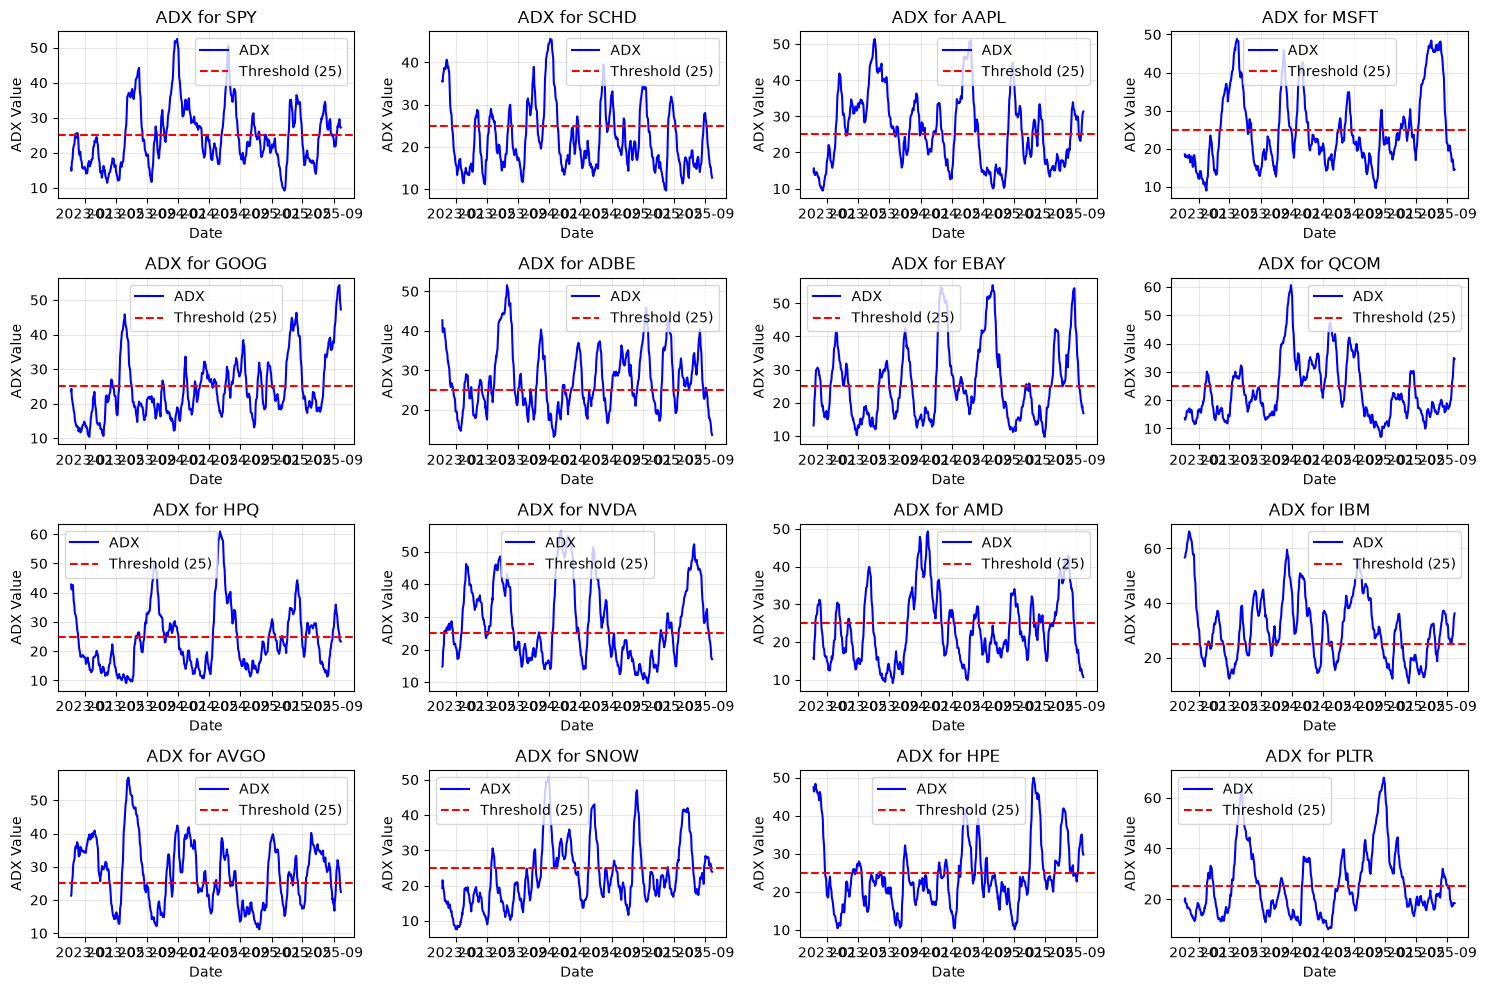

In [39]:
plt.figure(figsize=(15, 10))
for i, ticker in enumerate(tickers):
    plt.subplot(4, 4, i + 1)
    plt.plot(adx_data[ticker]['ADX'], label='ADX', color='blue')
    plt.axhline(y=25, color='red', linestyle='--', label='Threshold (25)')
    plt.title(f'ADX for {ticker}')
    plt.xlabel('Date')
    plt.ylabel('ADX Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
plt.tight_layout()

In [40]:
trending_tickers = [ticker for ticker in tickers if adx_data[ticker]['ADX'].iloc[-1] > 25]
trending_tickers.sort(key=lambda x: adx_data[x]['ADX'].iloc[-1], reverse=True)
trending_tickers

['GOOG', 'IBM', 'QCOM', 'AAPL', 'HPE', 'SPY']

From the ADX values, we can filter out the stocks that are currently trending and focus our momentum strategy on those.

In [41]:
STOCK = 'HPE'

In [42]:
stock = yf.Ticker(STOCK).history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True,
)
stock.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-10-03 00:00:00-04:00,11.003331,11.274572,10.867711,11.184158,14231900,0.0,0.0
2022-10-04 00:00:00-04:00,11.374028,11.618145,11.355946,11.618145,11791300,0.0,0.0
2022-10-05 00:00:00-04:00,11.446356,11.767325,11.374025,11.708555,11658700,0.0,0.0
2022-10-06 00:00:00-04:00,11.636226,11.744723,11.591020,11.672392,12361200,0.0,0.0
2022-10-07 00:00:00-04:00,11.446356,11.509645,11.193198,11.265529,12885200,0.0,0.0


## 1. Rate of Change (ROC)

The Rate of Change (ROC) is a momentum oscillator that measures the percentage change in price between the current price and the price a certain number of periods ago. It is calculated as follows:

$$
ROC_t(n) = \frac{P_t - P_{t-n}}{P_{t-n}}
$$

We can set a threshold for the ROC to determine when to enter or exit trades. For example, our trading rules could be:

- **No position (Flat)**
  - If $ROC_t(n) > \theta_{enter}$, we enter a long position.
  - If $ROC_t(n) < -\theta_{enter}$, we enter a short position.
- **Long position**
  - If $ROC_t(n) < \theta_{exit}$, we exit the long position.
- **Short position**
  - If $ROC_t(n) > -\theta_{exit}$, we exit the short position.

Now let's backtest our momentum strategy using the ROC indicator on HPE stock.

In [43]:
# Hyperparameters
n = 5
theta_enter = 0.05
theta_exit = 0.01
TRANSACTION_COST_RATE = 0.0010  # 10 bps per trade (commission + slippage)

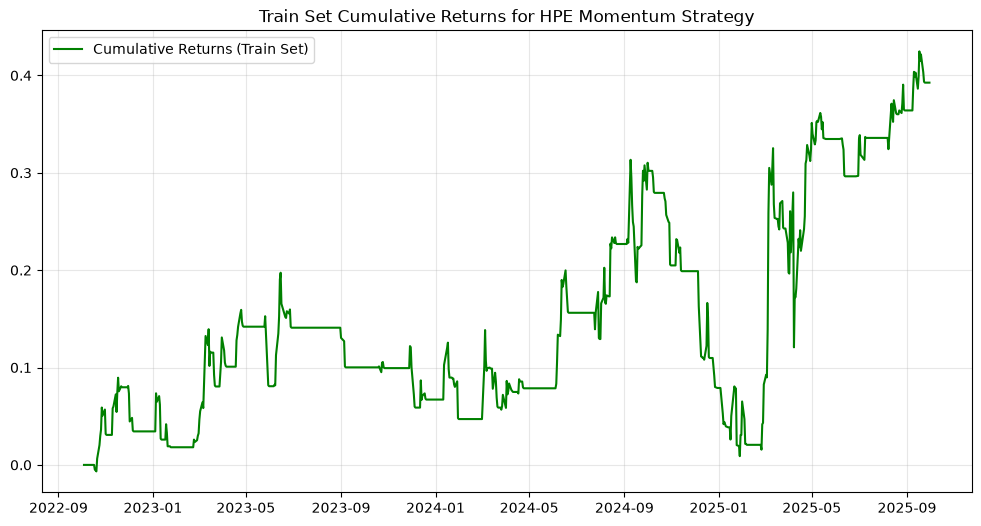

In [44]:
# Compute ROC
roc = stock['Close'].diff(n) / stock['Close'].shift(n)

portfolio_return_roc = pd.DataFrame(index=stock.index)

# Determine positions based on ROC
portfolio_return_roc['position'] = 0

current_pos = 0

for i in portfolio_return_roc.index:
    if current_pos == 0:
        if roc.loc[i] > theta_enter:
            current_pos = 1  # Enter long position
        elif roc.loc[i] < -theta_enter:
            current_pos = -1  # Enter short position
    elif current_pos == 1:
        if roc.loc[i] < theta_exit:
            current_pos = 0  # Exit long position
    elif current_pos == -1:
        if roc.loc[i] > -theta_exit:
            current_pos = 0  # Exit short position
    portfolio_return_roc.at[i, 'position'] = current_pos

# Compute daily returns
portfolio_return_roc['gross_return'] = stock['Close'].pct_change().shift(-1) * portfolio_return_roc['position']
portfolio_return_roc['trades'] = portfolio_return_roc['position'].diff().abs()
portfolio_return_roc['transaction_costs'] = portfolio_return_roc['trades'] * TRANSACTION_COST_RATE
portfolio_return_roc['net_return'] = portfolio_return_roc['gross_return'] - portfolio_return_roc['transaction_costs']

# Calculate Profit and Loss
pnl_train_roc = portfolio_return_roc[TRAIN_RANGE]['net_return'].cumsum()

# Plot the cumulative PnL
plt.figure(figsize=(12, 6))
plt.plot(pnl_train_roc, label='Cumulative Returns (Train Set)', color='green')
plt.title(f'Train Set Cumulative Returns for {STOCK} Momentum Strategy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [45]:
r_train_roc = portfolio_return_roc['net_return'][TRAIN_RANGE]
sharpe_train_roc = r_train_roc.mean() / (r_train_roc.std() + 1e-12) * np.sqrt(252)
print(f"Train Set Sharpe Ratio: {sharpe_train_roc:.4f}")

mdd_train_roc = (pnl_train_roc.cummax() - pnl_train_roc).max()
drawdown_trough_train_roc = (pnl_train_roc.cummax() - pnl_train_roc).idxmax()
drawdown_peak_train_roc = pnl_train_roc.loc[:drawdown_trough_train_roc].idxmax()
mdd_duration_train_roc = (drawdown_trough_train_roc - drawdown_peak_train_roc).days
print(f"Train Set Maximum Drawdown: {mdd_train_roc:.4f}")
print(f"Train Set Maximum Drawdown Duration: {mdd_duration_train_roc} days")

Train Set Sharpe Ratio: 0.5350
Train Set Maximum Drawdown: 0.3043
Train Set Maximum Drawdown Duration: 141 days


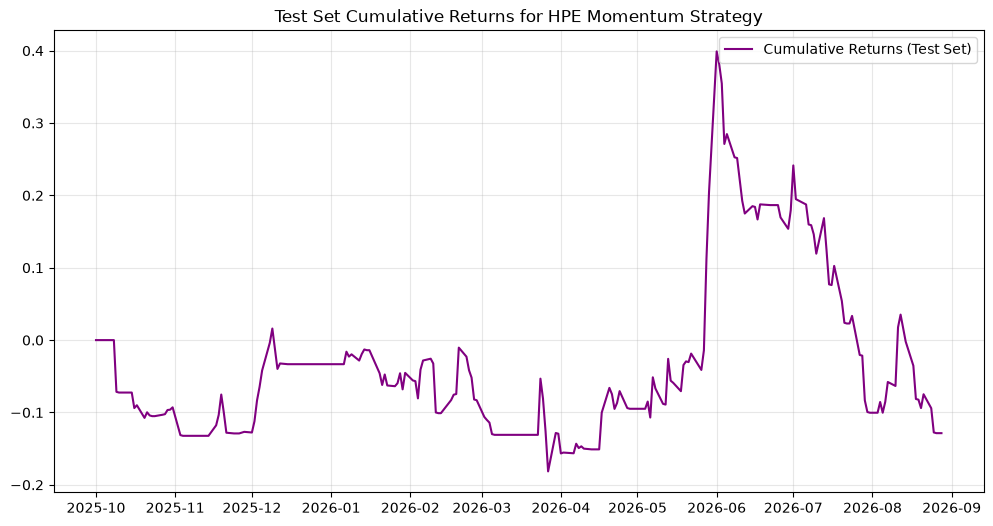

In [46]:
# Calculate Profit and Loss for test set
pnl_test_roc = portfolio_return_roc['net_return'][TEST_RANGE].cumsum()

# Plot the cumulative PnL for test set
plt.figure(figsize=(12, 6))
plt.plot(pnl_test_roc, label='Cumulative Returns (Test Set)', color='purple')
plt.title(f'Test Set Cumulative Returns for {STOCK} Momentum Strategy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [47]:
r_test_roc = portfolio_return_roc['net_return'][TEST_RANGE]
sharpe_test_roc = r_test_roc.mean() / (r_test_roc.std() + 1e-12) * np.sqrt(252)
print(f"Test Set Sharpe Ratio: {sharpe_test_roc:.4f}")

mdd_test_roc = (pnl_test_roc.cummax() - pnl_test_roc).max()
drawdown_trough_test_roc = (pnl_test_roc.cummax() - pnl_test_roc).idxmax()
drawdown_peak_test_roc = pnl_test_roc.loc[:drawdown_trough_test_roc].idxmax()
mdd_duration_test_roc = (drawdown_trough_test_roc - drawdown_peak_test_roc).days
print(f"Test Set Maximum Drawdown: {mdd_test_roc:.4f}")
print(f"Test Set Maximum Drawdown Duration: {mdd_duration_test_roc} days")

Test Set Sharpe Ratio: -0.3164
Test Set Maximum Drawdown: 0.5276
Test Set Maximum Drawdown Duration: 86 days


## 2. SMA Crossover

Simple Moving Average (SMA) crossover is another popular momentum strategy. It involves using two SMAs of different lengths: a short-term SMA and a long-term SMA. The basic idea is to generate buy and sell signals based on the crossover of these two SMAs.

- If $SMA_{short}(t) > SMA_{long}(t)$, it generates a buy signal.
- If $SMA_{short}(t) < SMA_{long}(t)$, it generates a sell signal.

In [48]:
# Hyperparameters
short_n = 20
long_n = 60
TRANSACTION_COST_RATE = 0.0010  # 10 bps per trade (commission + slippage)

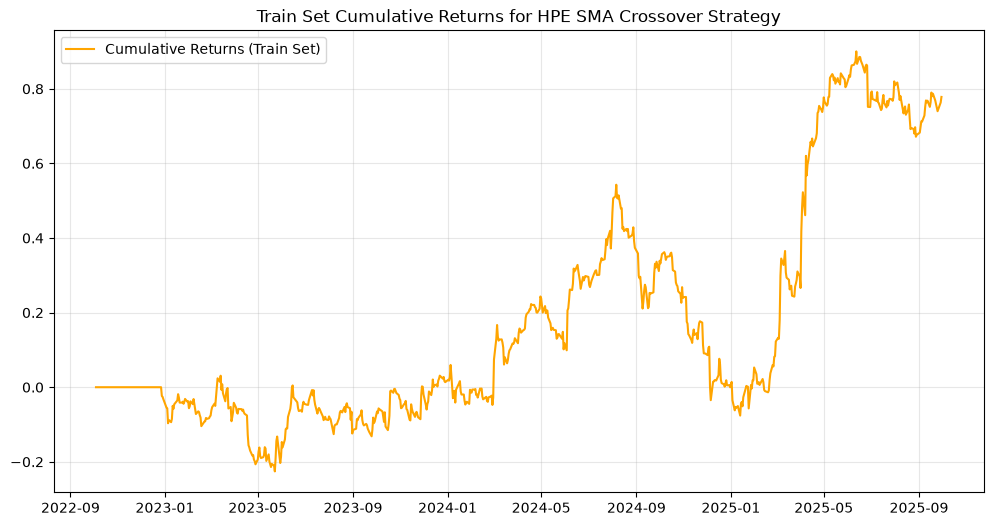

In [49]:
# Compute SMAs for train set
sma_short = (stock['Close'] - stock['Close'].shift(short_n)) / short_n
sma_long = (stock['Close'] - stock['Close'].shift(long_n)) / long_n

portfolio_return_sma = pd.DataFrame(index=stock.index)

# Determine positions based on SMA crossover for train set
portfolio_return_sma['position'] = np.where(sma_short > sma_long, 1, np.where(sma_short < sma_long, -1, 0))

# Compute daily returns for SMA strategy on train set
portfolio_return_sma['gross_return'] = stock['Close'].pct_change().shift(-1) * portfolio_return_sma['position']
portfolio_return_sma['trades'] = portfolio_return_sma['position'].diff().abs()
portfolio_return_sma['transaction_costs'] = portfolio_return_sma['trades'] * TRANSACTION_COST_RATE
portfolio_return_sma['net_return'] = portfolio_return_sma['gross_return'] - portfolio_return_sma['transaction_costs']

# Calculate Profit and Loss for SMA strategy on train set
pnl_train_sma = portfolio_return_sma[TRAIN_RANGE]['net_return'].cumsum()

# Plot the cumulative PnL for SMA strategy on train set
plt.figure(figsize=(12, 6))
plt.plot(pnl_train_sma, label='Cumulative Returns (Train Set)', color='orange')
plt.title(f'Train Set Cumulative Returns for {STOCK} SMA Crossover Strategy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [50]:
r_train_sma = portfolio_return_sma['net_return'][TRAIN_RANGE]
sharpe_train_sma = r_train_sma.mean() / (r_train_sma.std() + 1e-12) * np.sqrt(252)
print(f"Train Set Sharpe Ratio: {sharpe_train_sma:.4f}")

mdd_train = (pnl_train_sma.cummax() - pnl_train_sma).max()
drawdown_trough_train_sma = (pnl_train_sma.cummax() - pnl_train_sma).idxmax()
drawdown_peak_train_sma = pnl_train_sma.loc[:drawdown_trough_train_sma].idxmax()
mdd_duration_train_sma = (drawdown_trough_train_sma - drawdown_peak_train_sma).days
print(f"Train Set Maximum Drawdown: {mdd_train:.4f}")
print(f"Train Set Maximum Drawdown Duration: {mdd_duration_train_sma} days")

Train Set Sharpe Ratio: 0.7235
Train Set Maximum Drawdown: 0.6189
Train Set Maximum Drawdown Duration: 160 days


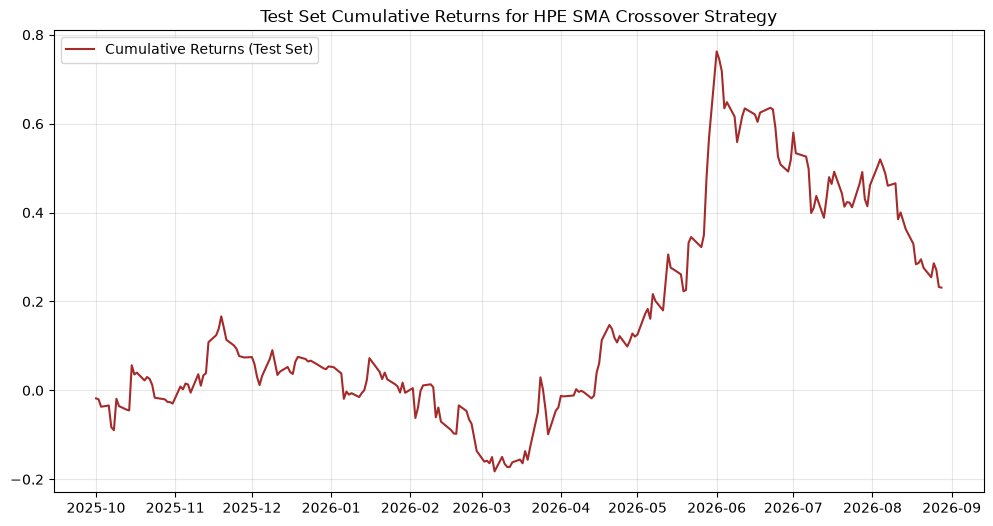

In [51]:
# Calculate Profit and Loss for SMA strategy on test set
pnl_test_sma = portfolio_return_sma['net_return'][TEST_RANGE].cumsum()

# Plot the cumulative PnL for SMA strategy on test set
plt.figure(figsize=(12, 6))
plt.plot(pnl_test_sma, label='Cumulative Returns (Test Set)', color='brown')
plt.title(f'Test Set Cumulative Returns for {STOCK} SMA Crossover Strategy')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [52]:
r_test_sma = portfolio_return_sma['net_return'][TEST_RANGE]
sharpe_test_sma = r_test_sma.mean() / (r_test_sma.std() + 1e-12) * np.sqrt(252)
print(f"Test Set Sharpe Ratio: {sharpe_test_sma:.4f}")

mdd_test_sma = (pnl_test_sma.cummax() - pnl_test_sma).max()
drawdown_trough_test_sma = (pnl_test_sma.cummax() - pnl_test_sma).idxmax()
drawdown_peak_test_sma = pnl_test_sma.loc[:drawdown_trough_test_sma].idxmax()
mdd_duration_test_sma = (drawdown_trough_test_sma - drawdown_peak_test_sma).days
print(f"Test Set Maximum Drawdown: {mdd_test_sma:.4f}")
print(f"Test Set Maximum Drawdown Duration: {mdd_duration_test_sma} days")

Test Set Sharpe Ratio: 0.4599
Test Set Maximum Drawdown: 0.5314
Test Set Maximum Drawdown Duration: 88 days
